FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/xz_plane.png'

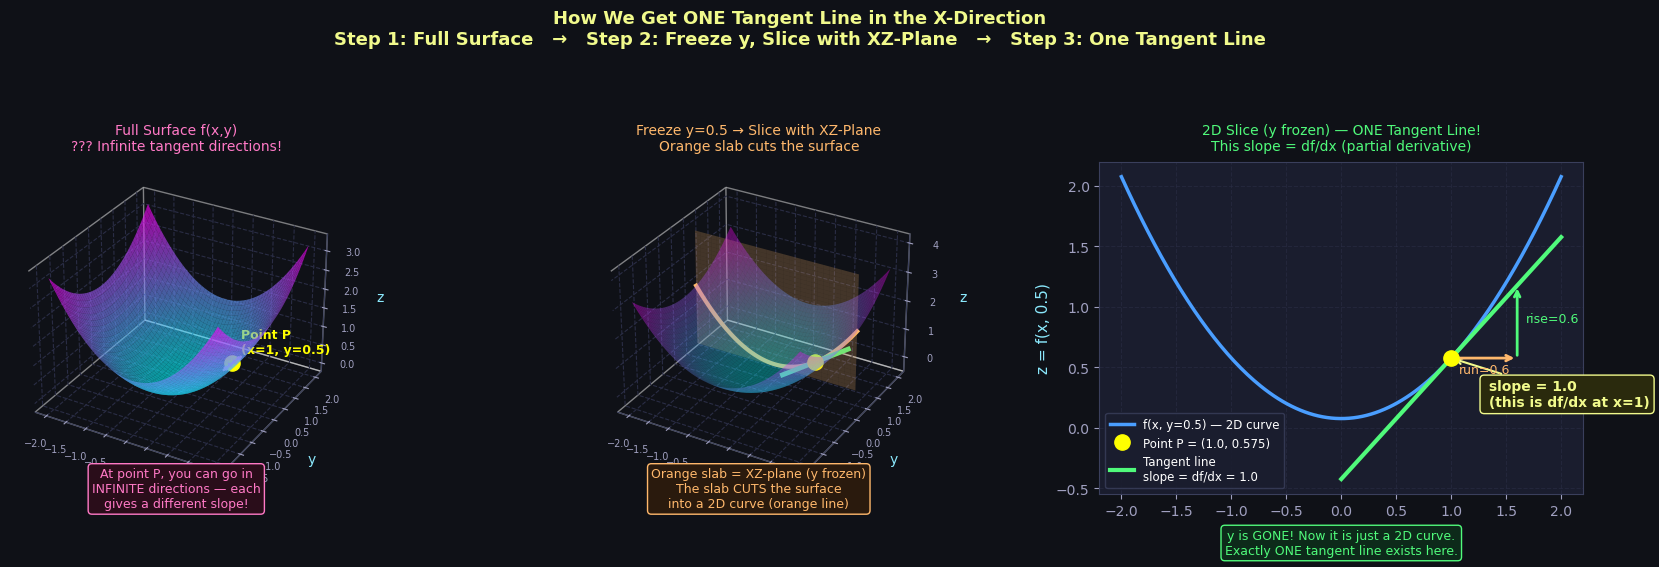

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'figure.facecolor': '#0F1117', 'text.color': 'white'})

# ── The surface f(x,y) = sin(x)*cos(y) ──────────────────────────────────────
f  = lambda x, y: 0.5*x**2 + 0.3*y**2      # simple bowl shape
x_ = np.linspace(-2, 2, 50)
y_ = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x_, y_)
Z = f(X, Y)

# The fixed point we study
x0, y0 = 1.0, 0.5
z0 = f(x0, y0)

fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor('#0F1117')
fig.suptitle(
    "How We Get ONE Tangent Line in the X-Direction\n"
    "Step 1: Full Surface   →   Step 2: Freeze y, Slice with XZ-Plane   →   Step 3: One Tangent Line",
    fontsize=13, fontweight='bold', color='#F1FA8C', y=1.01
)

# ════════════════════════════════════════════════════════════
# PANEL 1 — Full 3D surface with the point marked
# ════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_facecolor('#0F1117')
ax1.plot_surface(X, Y, Z, cmap='cool', alpha=0.6, linewidth=0)

# Mark the point P on the surface
ax1.scatter([x0], [y0], [z0], color='yellow', s=120, zorder=10)
ax1.text(x0+0.1, y0+0.2, z0+0.2, 'Point P\n(x=1, y=0.5)', color='yellow',
         fontsize=9, fontweight='bold')

# Draw MANY tangent arrows in different directions to show ambiguity
angle_list = np.linspace(0, 2*np.pi, 10, endpoint=False)
for angle in angle_list:
    dx = np.cos(angle) * 0.5
    dy = np.sin(angle) * 0.5
    dz = x0*dx + 0.3*y0*dy   # approximate slope in that direction
    ax1.quiver(x0, y0, z0, dx, dy, dz,
               color='#FF79C6', alpha=0.6, length=0.4, arrow_length_ratio=0.3)

ax1.set_title('Full Surface f(x,y)\n??? Infinite tangent directions!',
              color='#FF79C6', fontsize=10, pad=8)
ax1.set_xlabel('x', color='#8BE9FD')
ax1.set_ylabel('y', color='#8BE9FD')
ax1.set_zlabel('z', color='#8BE9FD')
ax1.tick_params(colors='#A0A0C0', labelsize=7)
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False
ax1.text2D(0.5, -0.04,
           "At point P, you can go in\nINFINITE directions — each\ngives a different slope!",
           transform=ax1.transAxes, ha='center', color='#FF79C6',
           fontsize=9,
           bbox=dict(boxstyle='round', facecolor='#2A0D1A', edgecolor='#FF79C6'))

# ════════════════════════════════════════════════════════════
# PANEL 2 — 3D surface with the XZ plane cutting through it
# ════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_facecolor('#0F1117')
ax2.plot_surface(X, Y, Z, cmap='cool', alpha=0.35, linewidth=0)

# Draw the XZ-plane (y = y0) as a transparent slab
x_plane = np.linspace(-2, 2, 30)
z_plane = np.linspace(0, 4, 30)
Xp, Zp  = np.meshgrid(x_plane, z_plane)
Yp      = np.full_like(Xp, y0)
ax2.plot_surface(Xp, Yp, Zp, color='#FFB86C', alpha=0.25)

# Draw the intersection curve (the slice)
x_slice = np.linspace(-2, 2, 100)
z_slice = f(x_slice, y0)          # f(x, y=0.5) — y is frozen!
ax2.plot(x_slice, np.full_like(x_slice, y0), z_slice,
         color='#FFB86C', lw=3, label='Slice curve')

# Mark point P
ax2.scatter([x0], [y0], [z0], color='yellow', s=120, zorder=10)

# Draw the tangent line IN the XZ plane only
dfdx = x0                          # derivative of 0.5x² = x
t = np.linspace(-0.8, 0.8, 30)
ax2.plot(x0 + t, np.full_like(t, y0), z0 + dfdx*t,
         color='#50FA7B', lw=3.5)

ax2.set_title('Freeze y=0.5 → Slice with XZ-Plane\nOrange slab cuts the surface',
              color='#FFB86C', fontsize=10, pad=8)
ax2.set_xlabel('x', color='#8BE9FD')
ax2.set_ylabel('y', color='#8BE9FD')
ax2.set_zlabel('z', color='#8BE9FD')
ax2.tick_params(colors='#A0A0C0', labelsize=7)
ax2.xaxis.pane.fill = False
ax2.yaxis.pane.fill = False
ax2.zaxis.pane.fill = False
ax2.text2D(0.5, -0.04,
           "Orange slab = XZ-plane (y frozen)\nThe slab CUTS the surface\ninto a 2D curve (orange line)",
           transform=ax2.transAxes, ha='center', color='#FFB86C',
           fontsize=9,
           bbox=dict(boxstyle='round', facecolor='#2A1A0D', edgecolor='#FFB86C'))

# ════════════════════════════════════════════════════════════
# PANEL 3 — The 2D slice: one clean curve, one tangent line
# ════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(133)
ax3.set_facecolor('#1A1D2E')

# The 2D curve f(x, y=y0)
x_2d  = np.linspace(-2, 2, 200)
z_2d  = f(x_2d, y0)
ax3.plot(x_2d, z_2d, color='#4A9EFF', lw=2.5, label='f(x, y=0.5) — 2D curve')

# Mark point P
ax3.plot(x0, z0, 'o', color='yellow', ms=11, zorder=5, label=f'Point P = ({x0}, {z0})')

# ONE tangent line — exactly one!
dfdx  = x0
t_2d  = np.linspace(x0 - 1.0, x0 + 1.0, 100)
z_tan = z0 + dfdx * (t_2d - x0)
ax3.plot(t_2d, z_tan, color='#50FA7B', lw=3,
         label=f'Tangent line\nslope = df/dx = {dfdx:.1f}')

# Annotate slope
ax3.annotate(
    f' slope = {dfdx:.1f}\n (this is df/dx at x=1)',
    xy=(x0, z0), xytext=(x0 + 0.3, z0 - 0.4),
    color='#F1FA8C', fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#F1FA8C', lw=1.5),
    bbox=dict(boxstyle='round', facecolor='#2A2A0D', edgecolor='#F1FA8C')
)

# Draw rise and run to show slope visually
run = 0.6
rise = dfdx * run
ax3.annotate('', xy=(x0 + run, z0), xytext=(x0, z0),
             arrowprops=dict(arrowstyle='->', color='#FFB86C', lw=2))
ax3.annotate('', xy=(x0 + run, z0 + rise), xytext=(x0 + run, z0),
             arrowprops=dict(arrowstyle='->', color='#50FA7B', lw=2))
ax3.text(x0 + run/2, z0 - 0.12, f'run={run}', ha='center',
         color='#FFB86C', fontsize=9)
ax3.text(x0 + run + 0.08, z0 + rise/2, f'rise={rise:.1f}',
         color='#50FA7B', fontsize=9)

ax3.set_title('2D Slice (y frozen) — ONE Tangent Line!\nThis slope = df/dx (partial derivative)',
              color='#50FA7B', fontsize=10, pad=8)
ax3.set_xlabel('x', color='#8BE9FD', fontsize=11)
ax3.set_ylabel('z = f(x, 0.5)', color='#8BE9FD', fontsize=11)
ax3.legend(fontsize=8.5, facecolor='#1A1D2E', edgecolor='#3A3F5C', labelcolor='white')
ax3.grid(True, color='#2A2D45', linestyle='--', alpha=0.6)
ax3.tick_params(colors='#A0A0C0')
ax3.text(0.5, -0.18,
         "y is GONE! Now it is just a 2D curve.\nExactly ONE tangent line exists here.",
         transform=ax3.transAxes, ha='center', color='#50FA7B',
         fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#0D2A1A', edgecolor='#50FA7B'))

plt.tight_layout(pad=2.5)
plt.savefig('/home/claude/xz_plane.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.close()
print("Done!")